In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from datasets import load_dataset

In [ ]:
emotion_dataset = load_dataset("dair-ai/emotion")

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.03MB            

split/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  127kB            

split/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  129kB            

split/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
train_text = emotion_dataset["train"]['text']

In [ ]:
train_label = emotion_dataset["train"]['label']

In [ ]:
train_text

Column(['i didnt feel humiliated', 'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake', 'im grabbing a minute to post i feel greedy wrong', 'i am ever feeling nostalgic about the fireplace i will know that it is still on the property', 'i am feeling grouchy'])

In [ ]:
test_text = emotion_dataset["test"]['text']
test_label = emotion_dataset["test"]['label']

In [ ]:
label_names = emotion_dataset["train"].features['label'].names

In [ ]:
for i in train_label:
  print(label_names[i])

Streaming output truncated to the last 5000 lines.
sadness
sadness
anger
fear
love
joy
anger
sadness
sadness
joy
fear
joy
fear
love
love
anger
anger
sadness
fear
sadness
sadness
surprise
love
joy
joy
love
sadness
joy
joy
fear
sadness
anger
anger
sadness
love
fear
fear
anger
anger
joy
sadness
sadness
joy
joy
fear
sadness
joy
love
fear
anger
sadness
joy
anger
surprise
fear
joy
joy
love
fear
sadness
joy
anger
fear
anger
sadness
sadness
sadness
anger
sadness
fear
joy
anger
anger
sadness
fear
joy
anger
fear
sadness
joy
fear
joy
love
anger
fear
fear
fear
fear
joy
anger
anger
sadness
joy
sadness
joy
sadness
sadness
joy
sadness
fear
fear
joy
sadness
joy
sadness
joy
fear
anger
sadness
joy
anger
joy
joy
sadness
joy
joy
anger
anger
joy
joy
joy
sadness
joy
joy
joy
anger
anger
joy
love
joy
love
joy
joy
joy
sadness
joy
sadness
surprise
sadness
anger
anger
anger
fear
fear
joy
fear
fear
joy
anger
joy
joy
joy
love
joy
fear
sadness
sadness
surprise
sadness
sadness
anger
joy
love
fear
joy
anger
joy
surpr

In [ ]:
df_train = pd.DataFrame(
    {
        "text": train_text,
        "label": [label_names[i] for i in train_label]
    },
)

In [ ]:
df_test = pd.DataFrame(
    {
        "text": test_text,
        "label": [label_names[i] for i in test_label]
    },
)

In [ ]:
df_train.head()

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [ ]:
df_test.head()

,text,label
0,im feeling rather rotten so im not very ambiti...,sadness
1,im updating my blog because i feel shitty,sadness
2,i never make her separate from me because i do...,sadness
3,i left with my bouquet of red and yellow tulip...,joy
4,i was feeling a little vain when i did this one,sadness


In [ ]:
df_train['label'].value_counts()

,count
label,
joy,5362
sadness,4666
anger,2159
fear,1937
love,1304
surprise,572


<Axes: xlabel='label', ylabel='count'>

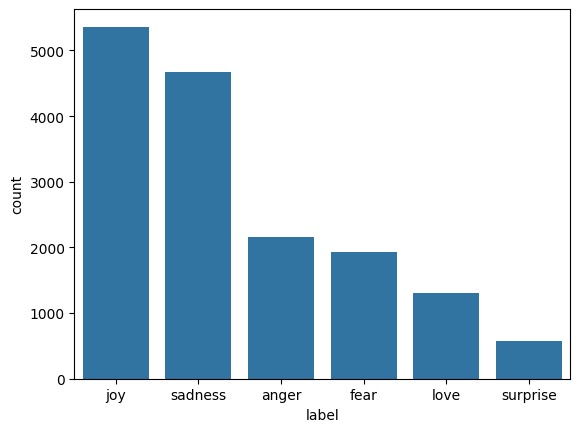

In [ ]:
sns.countplot(x='label', data=df_train,order=df_train['label'].value_counts().index)

In [ ]:
df_train.head()

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_words = 10000

tokenizer = Tokenizer(num_words=max_words,oov_token='<unk>')
tokenizer.fit_on_texts(df_train['text'])

train_sequence = tokenizer.texts_to_sequences(df_train['text'])
test_sequence = tokenizer.texts_to_sequences(df_test['text'])

In [ ]:
train_sequence

[[2, 139, 3, 679],
 [2,
  40,
  101,
  60,
  8,
  15,
  494,
  5,
  15,
  3496,
  553,
  32,
  60,
  61,
  128,
  148,
  76,
  1480,
  4,
  22,
  1255],
 [17, 3060, 7, 1149, 5, 286, 2, 3, 495, 438],
 [2, 24, 165, 8, 665, 27, 6, 4158, 2, 59, 47, 9, 13, 22, 72, 30, 6, 3497],
 [2, 24, 8, 1065],
 [73, 48, 8, 7, 56, 521, 319, 328, 158, 161, 9, 20],
 [73,
  48,
  329,
  35,
  7401,
  35,
  196,
  7402,
  888,
  4,
  73,
  2475,
  1384,
  7,
  159,
  1885,
  19,
  2,
  117,
  3,
  14,
  15,
  455],
 [2, 3, 29, 439, 27, 78, 29, 7, 1686, 35, 29, 760, 29, 7, 193, 267, 374],
 [2,
  21,
  48,
  25,
  5260,
  16,
  215,
  2,
  3,
  9,
  5260,
  99,
  5261,
  135,
  4,
  132,
  7,
  1038,
  4159],
 [2, 3, 666, 94],
 [2, 3, 14, 2, 21, 5, 80, 6, 733, 2, 93, 544, 304, 84],
 [2,
  39,
  3,
  9,
  483,
  22,
  7,
  530,
  440,
  4,
  9,
  2,
  40,
  920,
  5,
  21,
  69,
  840,
  10,
  1886,
  3061],
 [2, 70, 13, 90, 6, 5262, 52, 10, 193, 5, 3, 610],
 [2, 3, 339, 456, 2, 93, 32, 4160],
 [2,
  21,
  4161,

In [ ]:
padded_train_sequence = pad_sequences(train_sequence,maxlen=50,padding='post',truncating='post')
padded_test_sequence = pad_sequences(test_sequence,maxlen=50,padding='post',truncating='post')

In [ ]:
for i  in range(5):
  print(padded_train_sequence[i])

[  2 139   3 679   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
[   2   40  101   60    8   15  494    5   15 3496  553   32   60   61
  128  148   76 1480    4   22 1255    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0]
[  17 3060    7 1149    5  286    2    3  495  438    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0]
[   2   24  165    8  665   27    6 4158    2   59   47    9   13   22
   72   30    6 3497    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0]
[   2   24    8 1065    0    0 

In [ ]:
train_labels = np.array(train_label)
test_labels = np.array(test_label)

In [ ]:
train_labels

array([0, 0, 3, ..., 1, 3, 0])

In [ ]:
num_classes = len(np.unique(train_labels))
num_classes

6

In [ ]:
len(tokenizer.word_index)

15213

In [ ]:
padded_train_sequence.shape[1]

50

In [ ]:
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes = np.unique(train_labels),
    y = train_labels
)

class_weight_dict = dict(enumerate(class_weights))
class_weight_dict

{0: np.float64(0.5715102157451064),
 1: np.float64(0.49732686808404825),
 2: np.float64(2.044989775051125),
 3: np.float64(1.2351397251814111),
 4: np.float64(1.3766993632765445),
 5: np.float64(4.662004662004662)}

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN,Embedding,Dense,Dropout,LSTM,GRU

model = Sequential([
    Embedding(input_dim=max_words,output_dim=128,input_length=50),

    SimpleRNN(units=128,return_sequences=True),
    Dropout(0.5),

    SimpleRNN(units=64),
    Dropout(0.5),

    Dense(units=num_classes,activation='softmax'),
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.fit(
    padded_train_sequence,
    train_labels,
    epochs=20,
    batch_size=32,
    # validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.1531 - loss: 2.0406
Epoch 2/20
 19/500 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.1381 - loss: 1.9350

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1472 - loss: 1.8858
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.1259 - loss: 1.8266
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1270 - loss: 1.8080
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.1379 - loss: 1.8029
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.1411 - loss: 1.7995
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1475 - loss: 1.8026
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.1349 - loss: 1.8006
Epoch 9/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.1383 - loss: 1.7997
Epoch 10/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1437 - loss: 1.8018
Epoch 11/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.1423 - loss: 1.8022
Epoch 12/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1353 - loss: 1.8026
Epoch 13/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - ac

In [ ]:
rnn_loss,rnn_accuracy = model.evaluate(padded_test_sequence,test_labels)
print("RNN Loss :",rnn_loss)
print("RNN Accuracy :",rnn_accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.0795 - loss: 1.8574
RNN Loss : 1.8574316501617432
RNN Accuracy : 0.0794999971985817


In [ ]:
LSTM_model = Sequential([
    Embedding(input_dim=max_words,output_dim=128,input_length=50),

    LSTM(units=128,return_sequences=True),
    Dropout(0.5),

    LSTM(units=64),
    Dropout(0.5),

    Dense(units=num_classes,activation='softmax'),
])

LSTM_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)



LSTM_model.fit(
    padded_train_sequence,
    train_labels,
    epochs=20,
    batch_size=32,
    # validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)
print(LSTM_model.summary())

LSTM__loss,LSTM__accuracy = LSTM_model.evaluate(padded_test_sequence,test_labels)
print("LSTM Loss :",LSTM__loss)
print("LSTM Accuracy :",LSTM__accuracy)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.1583 - loss: 1.7955
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1476 - loss: 1.7939
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.1713 - loss: 1.7925
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.2370 - loss: 1.7528
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.4244 - loss: 1.3688
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.7124 - loss: 0.8949
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8232 - loss: 0.6006
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8920 - loss: 0.3699
Epoch 9/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9158 - loss: 0.2774
Epoch 10/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9240 - loss: 0.2502
Epoch 11/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9318 - loss: 0.2053
Epoch 12/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 1

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (32, 50, 128)          │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (32, 50, 128)          │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (32, 50, 128)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (32, 64)               │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (32, 64)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (32, 6)                │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,384,148 (16.72 MB)

 Trainable params: 1,461,382 (5.57 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,922,766 (11.15 MB)

None
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9140 - loss: 0.3035
LSTM Loss : 0.3034994900226593
LSTM Accuracy : 0.9139999747276306


In [ ]:
GRU_model = Sequential([
    Embedding(input_dim=max_words,output_dim=128,input_length=50),

    GRU(units=128,return_sequences=True),
    Dropout(0.5),

    GRU(units=64),
    Dropout(0.5),

    Dense(units=num_classes,activation='softmax'),
])

GRU_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)



GRU_model.fit(
    padded_train_sequence,
    train_labels,
    epochs=20,
    batch_size=32,
    # validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)
print(GRU_model.summary())

GRU__loss,GRU__accuracy = GRU_model.evaluate(padded_test_sequence,test_labels)
print("GRU Loss :",GRU__loss)
print("GRU Accuracy :",GRU__accuracy)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.1545 - loss: 1.7973
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.1618 - loss: 1.7946
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.1663 - loss: 1.7943
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.1730 - loss: 1.7932
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.1597 - loss: 1.7894
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1698 - loss: 1.7699
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.1979 - loss: 1.7289
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.2399 - loss: 1.6689
Epoch 9/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.2981 - loss: 1.5584
Epoch 10/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.3457 - loss: 1.4143
Epoch 11/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.4218 - loss: 1.2518
Epoch 12/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (32, 50, 128)          │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (32, 50, 128)          │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (32, 50, 128)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (32, 64)               │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (32, 64)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (32, 6)                │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,250,132 (16.21 MB)

 Trainable params: 1,416,710 (5.40 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,833,422 (10.81 MB)

None
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5775 - loss: 2.0535
GRU Loss : 2.0535354614257812
GRU Accuracy : 0.5774999856948853


In [ ]:
result_df = pd.DataFrame({
    'Model': ['RNN', 'LSTM', 'GRU'],
    'Loss': [rnn_loss, LSTM__loss, GRU__loss],
    'Accuracy': [rnn_accuracy, LSTM__accuracy, GRU__accuracy]
}).sort_values(by='Accuracy',ascending=False)
result_df = result_df.set_index('Model')
result_df

,Loss,Accuracy
Model,,
LSTM,0.303499,0.9140
GRU,2.053535,0.5775
RNN,1.857432,0.0795


In [ ]:
from tensorflow.keras.layers import Bidirectional

BIGRU = Sequential([
    Embedding(input_dim=max_words,output_dim=300,input_length=50),

    Bidirectional(GRU(units=128,return_sequences=True)),
    Dropout(0.5),

    Bidirectional(GRU(units=64)),
    Dropout(0.5),

    Dense(units=num_classes,activation='softmax'),
])


BIGRU.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

BIGRU.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
BIGRU.fit(
    padded_train_sequence,
    train_labels,
    epochs=20,
    batch_size=32,
    #validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.5738 - loss: 1.0196
Epoch 2/20


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9191 - loss: 0.2391
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.9435 - loss: 0.1549
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.9602 - loss: 0.1078
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9719 - loss: 0.0778
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.9747 - loss: 0.0708
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9759 - loss: 0.0667
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9815 - loss: 0.0535
Epoch 9/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9872 - loss: 0.0352
Epoch 10/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9858 - loss: 0.0411
Epoch 11/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9849 - loss: 0.0436
Epoch 12/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9888 - loss: 0.0340
Epoch 13/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms

In [ ]:
BIGRU_loss,BIGRU_accuracy = BIGRU.evaluate(padded_test_sequence,test_labels)
print("BIGRU Loss :",BIGRU_loss)
print("BIGRU Accuracy :",BIGRU_accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.9170 - loss: 0.4206
BIGRU Loss : 0.4206102788448334
BIGRU Accuracy : 0.9169999957084656


In [ ]:
from sklearn.metrics import confusion_matrix

BIGRU_predictions = np.argmax(BIGRU.predict(padded_test_sequence),axis=1)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


In [ ]:
BIGRU_predictions

array([0, 0, 0, ..., 1, 1, 5])

<Axes: >

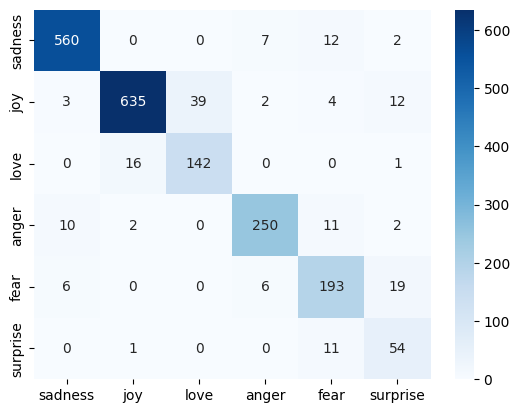

In [ ]:
sns.heatmap(confusion_matrix(test_labels,BIGRU_predictions),annot=True,fmt='d',cmap="Blues",xticklabels=label_names,yticklabels=label_names)

In [ ]:
sample_text = [
    "I am feeling very happy today after hearing the good news!",
    "This is making me so angry, I can't believe it.",
    "I feel so sad and lonely right now.",
    "I'm completely surprised by this outcome, it's amazing!",
    "I am so afraid of what might happen next.",
    "I'm in love with this beautiful scenery."
]


sample_sequences = tokenizer.texts_to_sequences(sample_text)

padded_sample_sequences = pad_sequences(sample_sequences, maxlen=50, padding='post', truncating='post')

sample_predictions = np.argmax(BIGRU.predict(padded_sample_sequences), axis=1)

print("Predicted emotions for sample sentences:")
for i, sentence in enumerate(sample_text):
    predicted_label = label_names[sample_predictions[i]]
    print(f"Sentence: '{sentence}' -> \nPredicted Emotion: {predicted_label}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
Predicted emotions for sample sentences:
Sentence: 'I am feeling very happy today after hearing the good news!' -> 
Predicted Emotion: joy
Sentence: 'This is making me so angry, I can't believe it.' -> 
Predicted Emotion: anger
Sentence: 'I feel so sad and lonely right now.' -> 
Predicted Emotion: sadness
Sentence: 'I'm completely surprised by this outcome, it's amazing!' -> 
Predicted Emotion: surprise
Sentence: 'I am so afraid of what might happen next.' -> 
Predicted Emotion: fear
Sentence: 'I'm in love with this beautiful scenery.' -> 
Predicted Emotion: joy


In [ ]:
import os
import pickle

model_dir = 'Artifacts'
os.makedirs(model_dir, exist_ok=True)

In [ ]:
BIGRU.save(os.path.join(model_dir,'BIGRU_model.keras'))

with open(os.path.join(model_dir,'tokenizer.pkl'),'wb') as file:
  pickle.dump(tokenizer,file)